<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/00_build_candidate_database_colab_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/00_build_candidate_database_colab.ipynb"
   target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg"
       alt="Open In Colab"/>
</a>

# Build the ORR Bimetallic Bulk Candidate Database

**A reproducible Materials Project–Open Catalyst workflow for constructing the
frozen 185-bulk inventory used in the associated multi-fidelity ORR screening
study.**

The notebook begins with the Open Catalyst bulk database, selects binary
structures formed from 14 elements, resolves legacy Materials Project source
identifiers to current canonical material IDs, retrieves crystallographic and
thermodynamic metadata, and reproduces the exact manuscript dataset.

## Screening workflow

<div align="center">

**11,410 OC bulk records**  
↓  
**273 binary candidates**  
↓  
**259 canonical Materials Project materials**  
↓  
**185 satisfying the current structural criteria**

</div>

## Surface-generation space

<div align="center">

**185 retained bulk structures**  
×  
**3 low-index orientations: (111), (110), and (100)**  
=  
**555 bulk–facet systems**

</div>

> ### Saved-output snapshot
>
> The tables and figures displayed below are retained from the validated
> reference run used to construct the 185-bulk inventory. They are intentionally
> stored in the notebook so that GitHub visitors can inspect the results without
> executing the Materials Project API workflow.
>
> Rerunning the notebook in Colab may return updated canonical MP identifiers or
> metadata because Materials Project is an evolving database. The two explicit
> dataset-freeze exclusions preserve consistency with the calculations reported
> in the associated manuscript.

## Contents

1. [Colab setup](#colab-setup)
2. [Data sources](#data-sources)
3. [Load the OC bulk database](#load-oc)
4. [Select the binary chemical space](#binary-space)
5. [Map legacy OC IDs to current MP IDs](#id-mapping)
6. [Retrieve MP crystallographic metadata](#mp-metadata)
7. [Reproduce the frozen 185-bulk inventory](#frozen-inventory)
8. [Validate crystallographic counts](#validation)
9. [Export the database](#export)
10. [Analyze bimetallic-pair coverage](#pair-coverage)
11. [Compare formation energies](#formation-energy)
12. [References](#references)

<a name="colab-setup"></a>
## 1. Colab setup

The workflow uses a CPU runtime. In Colab, run the installation cell once after
connecting to a runtime. The version ranges keep the notebook compatible with
current Colab runtimes while avoiding unnecessary upgrades of the complete
scientific stack.

In [1]:
%pip install -q "mp-api>=0.41,<1" "ase>=3.22,<4" "pandas>=2,<3" \
    "matplotlib>=3.7,<4" "tqdm>=4.65"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━

In [2]:
import os
import pickle
import sys
from getpass import getpass
from itertools import combinations
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mp_api.client import MPRester
from tqdm.auto import tqdm

IN_COLAB = "google.colab" in sys.modules

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print("Running in Google Colab:", IN_COLAB)

Running in Google Colab: True


### Materials Project API key

For Colab, add a secret named **`MP_API_KEY`** using the key icon in the
left-hand sidebar. The notebook reads it through `google.colab.userdata`.
Outside Colab, set the `MP_API_KEY` environment variable. A hidden prompt is
used only as a final fallback.

The key is never printed or saved in the notebook.

In [3]:
def get_mp_api_key() -> str:
    # Read the MP API key without storing it in notebook source.
    api_key = os.getenv("MP_API_KEY", "").strip()

    if IN_COLAB and not api_key:
        try:
            from google.colab import userdata
            api_key = (userdata.get("MP_API_KEY") or "").strip()
        except Exception:
            api_key = ""

    if not api_key:
        api_key = getpass("Materials Project API key: ").strip()

    if not api_key:
        raise ValueError(
            "No Materials Project API key was provided. "
            "Add an MP_API_KEY Colab secret or environment variable."
        )

    return api_key


MP_API_KEY = get_mp_api_key()

ELEMENT_ORDER = [
    "Ir", "Pt", "Ru", "Ni", "Fe", "Mo", "Ta",
    "Nb", "Ti", "Cu", "Sb", "Mn", "Co", "Sn",
]
TARGET_ELEMENTS = set(ELEMENT_ORDER)

BULKS_PATH = Path("data/bulks.pkl")
ID_MAP_CACHE = Path("data/oc20_to_current_mp_id.csv")
OUTPUT_DIR = Path("data/selected_bulks")
FIGURE_DIR = Path("figures")

for directory in [
    BULKS_PATH.parent,
    ID_MAP_CACHE.parent,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Elements:", len(ELEMENT_ORDER))
print("Possible binary systems:", len(list(combinations(ELEMENT_ORDER, 2))))

Elements: 14
Possible binary systems: 91


<a name="data-sources"></a>
## 2. Data sources

The workflow combines two complementary resources:

- **Open Catalyst Dataset:** `bulks.pkl` provides consistently represented bulk
  structures and legacy Materials Project source identifiers.
- **Materials Project:** the API provides the current canonical material ID,
  chemical system, formula, symmetry, formation energy, hull distance, band gap,
  and experimental/theoretical status.

The OC bulk file is downloaded automatically when it is absent.

In [4]:
BULKS_URL = (
    "https://raw.githubusercontent.com/Open-Catalyst-Project/"
    "Open-Catalyst-Dataset/main/ocdata/databases/pkls/bulks.pkl"
)

if not BULKS_PATH.exists():
    urlretrieve(BULKS_URL, BULKS_PATH)
    print(f"Downloaded: {BULKS_PATH}")
else:
    print(f"Using existing file: {BULKS_PATH}")

Downloaded: data/bulks.pkl


<a name="load-oc"></a>
## 3. Load the OC bulk database

In [5]:
with BULKS_PATH.open("rb") as handle:
    bulks = pickle.load(handle)

print("Database type:", type(bulks))
print("Number of entries:", len(bulks))
print("First-entry keys:", bulks[0].keys())

assert len(bulks) == 11_410

Database type: <class 'list'>
Number of entries: 11410
First-entry keys: dict_keys(['atoms', 'src_id', 'bulk_sampling_str'])


<a name="binary-space"></a>
## 4. Select the binary chemical space

Only binary structures composed entirely of the 14 target elements are kept.
The original OC bulk index is retained because it is needed to recover the
corresponding structure from `bulks.pkl`.

In [6]:
candidate_rows = []

for bulk_index, record in enumerate(bulks):
    atoms = record["atoms"]
    elements = sorted(set(atoms.get_chemical_symbols()))

    if len(elements) == 2 and set(elements).issubset(TARGET_ELEMENTS):
        candidate_rows.append(
            {
                "bulk_index": bulk_index,
                "source_id": str(record["src_id"]),
                "formula_oc20": atoms.get_chemical_formula(),
                "elements": elements,
                "n_atoms": len(atoms),
            }
        )

candidates = (
    pd.DataFrame(candidate_rows)
    .drop_duplicates("source_id")
    .reset_index(drop=True)
)

print("Binary OC20 candidates:", len(candidates))

assert candidates["source_id"].is_unique
assert len(candidates) == 273

candidates.head()

Binary OC20 candidates: 273


,bulk_index,source_id,formula_oc20,elements,n_atoms
0,235,mp-2083,IrSn2,"[Ir, Sn]",3
1,237,mp-20536,Co3Sn3,"[Co, Sn]",6
2,257,mp-10598,Cu2Sn2,"[Cu, Sn]",4
3,282,mp-1030,Pt7Sb,"[Pt, Sb]",8
4,288,mp-2260,FePt,"[Fe, Pt]",2


<a name="id-mapping"></a>
## 5. Map legacy OC IDs to current MP IDs

The OC file contains legacy MP source/task identifiers. Because several legacy
records can now resolve to one canonical MP material, each source ID is mapped
explicitly and the result is cached locally.

The first API mapping run can take a few minutes. Later runs reuse
`data/oc20_to_current_mp_id.csv`.

In [7]:
if ID_MAP_CACHE.exists():
    id_map = pd.read_csv(ID_MAP_CACHE, dtype=str)
    print("Loaded cached ID mapping:", ID_MAP_CACHE)

else:
    mapping_rows = []

    with MPRester(
        MP_API_KEY,
        use_document_model=False,
        mute_progress_bars=True,
    ) as mpr:
        for source_id in tqdm(
            candidates["source_id"],
            desc="Mapping legacy OC IDs",
        ):
            result = mpr.materials.search(
                task_ids=[source_id],
                fields=["material_id"],
                all_fields=False,
            )

            matched_ids = sorted(
                {
                    str(doc["material_id"])
                    for doc in result
                    if doc.get("material_id") is not None
                }
            )

            mapping_rows.append(
                {
                    "source_id": source_id,
                    "current_material_id": (
                        matched_ids[0] if len(matched_ids) == 1 else pd.NA
                    ),
                    "n_material_matches": len(matched_ids),
                }
            )

    id_map = pd.DataFrame(mapping_rows)
    id_map.to_csv(ID_MAP_CACHE, index=False)
    print("Saved ID mapping:", ID_MAP_CACHE)

if "n_material_matches" not in id_map:
    id_map["n_material_matches"] = 1

invalid_mapping = id_map[
    id_map["current_material_id"].isna()
    | (id_map["n_material_matches"].astype(int) != 1)
]

print("Mapped IDs:", id_map["current_material_id"].notna().sum())
print("Unmapped or ambiguous IDs:", len(invalid_mapping))

if not invalid_mapping.empty:
    display(invalid_mapping)
    raise ValueError(
        "Every legacy OC source ID must map to exactly one current MP material."
    )

id_map.head()

Mapping legacy OC IDs:   0%|          | 0/273 [00:00<?, ?it/s]

Saved ID mapping: data/oc20_to_current_mp_id.csv
Mapped IDs: 273
Unmapped or ambiguous IDs: 0


,source_id,current_material_id,n_material_matches
0,mp-2083,mp-aaaaadcd,1
1,mp-20536,mp-aaaabejw,1
2,mp-10598,mp-aaaaaprq,1
3,mp-1030,mp-aaaaabnq,1
4,mp-2260,mp-aaaaadiy,1


In [8]:
candidate_map = candidates.merge(
    id_map[["source_id", "current_material_id"]],
    on="source_id",
    how="left",
    validate="one_to_one",
)

print("Candidates with mapped MP IDs:", len(candidate_map))
candidate_map.head()

Candidates with mapped MP IDs: 273


,bulk_index,source_id,formula_oc20,elements,n_atoms,current_material_id
0,235,mp-2083,IrSn2,"[Ir, Sn]",3,mp-aaaaadcd
1,237,mp-20536,Co3Sn3,"[Co, Sn]",6,mp-aaaabejw
2,257,mp-10598,Cu2Sn2,"[Cu, Sn]",4,mp-aaaaaprq
3,282,mp-1030,Pt7Sb,"[Pt, Sb]",8,mp-aaaaabnq
4,288,mp-2260,FePt,"[Fe, Pt]",2,mp-aaaaadiy


<a name="mp-metadata"></a>
## 6. Retrieve MP crystallographic metadata

The current canonical IDs are queried in batches. `use_document_model=False`
returns plain dictionaries and avoids local document-model validation problems
when MP introduces new identifier formats.

In [9]:
current_material_ids = sorted(
    candidate_map["current_material_id"].unique()
)

BATCH_SIZE = 50
summary_docs = []

with MPRester(
    MP_API_KEY,
    use_document_model=False,
    mute_progress_bars=True,
) as mpr:
    for start in range(0, len(current_material_ids), BATCH_SIZE):
        batch = current_material_ids[start : start + BATCH_SIZE]

        batch_docs = mpr.materials.summary.search(
            material_ids=batch,
            fields=[
                "material_id",
                "chemsys",
                "formula_pretty",
                "symmetry",
                "volume",
                "formation_energy_per_atom",
                "energy_above_hull",
                "band_gap",
                "theoretical",
            ],
            all_fields=False,
        )

        summary_docs.extend(batch_docs)

        print(
            f"Batch {start // BATCH_SIZE + 1}: "
            f"requested {len(batch)}, returned {len(batch_docs)}"
        )

Batch 1: requested 50, returned 50
Batch 2: requested 50, returned 50
Batch 3: requested 50, returned 50
Batch 4: requested 50, returned 50
Batch 5: requested 50, returned 50
Batch 6: requested 9, returned 9


In [10]:
mp_rows = []

for doc in summary_docs:
    symmetry = doc.get("symmetry") or {}
    theoretical = doc.get("theoretical")

    mp_rows.append(
        {
            "current_material_id": str(doc.get("material_id")),
            "chemsys": doc.get("chemsys"),
            "formula_pretty": doc.get("formula_pretty"),
            "crystal_system": symmetry.get("crystal_system"),
            "spacegroup": symmetry.get("symbol"),
            "spacegroup_number": symmetry.get("number"),
            "volume": doc.get("volume"),
            "formation_energy_per_atom": doc.get(
                "formation_energy_per_atom"
            ),
            "energy_above_hull": doc.get("energy_above_hull"),
            "band_gap": doc.get("band_gap"),
            "experimentally_observed": (
                not bool(theoretical)
                if theoretical is not None
                else pd.NA
            ),
        }
    )

mp_data = (
    pd.DataFrame(mp_rows)
    .drop_duplicates("current_material_id")
    .reset_index(drop=True)
)

print("Unique MP symmetry records:", len(mp_data))
assert len(mp_data) == 259

mp_data.head()

Unique MP symmetry records: 259


,current_material_id,chemsys,formula_pretty,crystal_system,spacegroup,spacegroup_number,volume,formation_energy_per_atom,energy_above_hull,band_gap,experimentally_observed
0,mp-aaaaaakf,Ir-Ta,TaIr3,Cubic,Pm-3m,221,59.561546,-0.757642,0.000000,0.0,True
1,mp-aaaaaako,Nb-Sb,Nb5Sb4,Tetragonal,I4/m,87,194.341774,-0.360486,0.000000,0.0,True
2,mp-aaaaaalt,Fe-Ti,TiFe,Cubic,Pm-3m,221,25.377989,-0.420830,0.000000,0.0,True
3,mp-aaaaaaqq,Nb-Ru,NbRu,Tetragonal,P4/mmm,123,31.933825,-0.198144,0.035461,0.0,True
4,mp-aaaaaauv,Sb-Ta,Ta3Sb,Cubic,Pm-3n,223,146.788349,-0.147627,0.000000,0.0,True


In [11]:
df = candidate_map.merge(
    mp_data,
    on="current_material_id",
    how="left",
    validate="many_to_one",
)

missing_symmetry = df["spacegroup"].isna().sum()

print("OC20 candidates:", len(df))
print("Candidates without MP symmetry:", missing_symmetry)

if missing_symmetry:
    display(
        df.loc[
            df["spacegroup"].isna(),
            ["source_id", "current_material_id", "formula_oc20"],
        ]
    )
    raise ValueError(
        f"{missing_symmetry} candidates lack MP symmetry metadata."
    )

df.head()

OC20 candidates: 273
Candidates without MP symmetry: 0


,bulk_index,source_id,formula_oc20,elements,n_atoms,current_material_id,chemsys,formula_pretty,crystal_system,spacegroup,spacegroup_number,volume,formation_energy_per_atom,energy_above_hull,band_gap,experimentally_observed
0,235,mp-2083,IrSn2,"[Ir, Sn]",3,mp-aaaaadcd,Ir-Sn,Sn2Ir,Cubic,Fm-3m,225,64.528970,-0.310802,0.000000,0.0,True
1,237,mp-20536,Co3Sn3,"[Co, Sn]",6,mp-aaaabejw,Co-Sn,CoSn,Hexagonal,P6/mmm,191,99.806980,-0.095880,0.000000,0.0,True
2,257,mp-10598,Cu2Sn2,"[Cu, Sn]",4,mp-aaaaaprq,Cu-Sn,CuSn,Hexagonal,P6_3/mmc,194,74.465158,0.009224,0.009224,0.0,True
3,282,mp-1030,Pt7Sb,"[Pt, Sb]",8,mp-aaaaabnq,Pt-Sb,SbPt7,Cubic,Fm-3m,225,127.520686,-0.114505,0.009764,0.0,True
4,288,mp-2260,FePt,"[Fe, Pt]",2,mp-aaaaadiy,Fe-Pt,FePt,Tetragonal,P4/mmm,123,27.813428,-0.231996,0.000000,0.0,True


<a name="frozen-inventory"></a>
## 7. Reproduce the frozen 185-bulk inventory

The structural screen retains 16 nontrigonal space groups. Multiple legacy
source IDs that map to the same canonical MP material are consolidated by
keeping the record with the lowest OC bulk index.

Two valid materials appear in the current remapping but were not part of the
frozen inventory used for the subsequent slab and adsorption calculations:

- `mp-568067`: NiPt, \(P4/mmm\);
- `mp-1077083`: FeSb\(_2\), \(Pnnm\).

They are stable and experimentally reported in the current MP metadata.
Accordingly, they are recorded as **dataset-version exclusions**, not rejected
for thermodynamic or chemical reasons.

In [12]:
EXPECTED_STRUCTURE_TYPES = pd.DataFrame(
    [
        ("Hexagonal",    "P6_3/mmc",  "P6$_3$/mmc",      46),
        ("Cubic",        "Pm-3m",     "Pm$\\bar{3}$m",   37),
        ("Tetragonal",   "P4/mmm",    "P4/mmm",          18),
        ("Tetragonal",   "I4/mmm",    "I4/mmm",          14),
        ("Cubic",        "Pm-3n",     "Pm$\\bar{3}$n",   11),
        ("Cubic",        "Fm-3m",     "Fm$\\bar{3}$m",   11),
        ("Orthorhombic", "Pmmn",      "Pmmn",             9),
        ("Orthorhombic", "Pmma",      "Pmma",             7),
        ("Cubic",        "Fd-3m",     "Fd$\\bar{3}$m",    7),
        ("Tetragonal",   "I4/mcm",    "I4/mcm",           5),
        ("Orthorhombic", "Immm",      "Immm",             5),
        ("Cubic",        "Im-3m",     "Im$\\bar{3}$m",    4),
        ("Hexagonal",    "P-6m2",     "P$\\bar{6}$m2",    4),
        ("Orthorhombic", "Cmmm",      "Cmmm",             4),
        ("Orthorhombic", "Pnnm",      "Pnnm",             2),
        ("Orthorhombic", "Fmmm",      "Fmmm",             1),
    ],
    columns=[
        "crystal_system",
        "spacegroup",
        "spacegroup_latex",
        "expected_count",
    ],
)

SELECTED_SPACEGROUPS = set(EXPECTED_STRUCTURE_TYPES["spacegroup"])

EXPECTED_STRUCTURE_TYPES

,crystal_system,spacegroup,spacegroup_latex,expected_count
0,Hexagonal,P6_3/mmc,P6$_3$/mmc,46
1,Cubic,Pm-3m,Pm$\bar{3}$m,37
2,Tetragonal,P4/mmm,P4/mmm,18
3,Tetragonal,I4/mmm,I4/mmm,14
4,Cubic,Pm-3n,Pm$\bar{3}$n,11
5,Cubic,Fm-3m,Fm$\bar{3}$m,11
6,Orthorhombic,Pmmn,Pmmn,9
7,Orthorhombic,Pmma,Pmma,7
8,Cubic,Fd-3m,Fd$\bar{3}$m,7
9,Tetragonal,I4/mcm,I4/mcm,5


In [13]:
canonical_df = (
    df
    .sort_values(["current_material_id", "bulk_index", "source_id"])
    .drop_duplicates("current_material_id", keep="first")
    .reset_index(drop=True)
)

selected_before_freeze = canonical_df[
    (canonical_df["crystal_system"] != "Trigonal")
    & canonical_df["spacegroup"].isin(SELECTED_SPACEGROUPS)
].copy()

DATASET_FREEZE_EXCLUSIONS = {
    "mp-568067": (
        "Valid NiPt (P4/mmm) structure recovered by the current MP mapping, "
        "but outside the frozen 185-bulk manuscript inventory."
    ),
    "mp-1077083": (
        "Valid FeSb2 (Pnnm) structure recovered by the current MP mapping, "
        "but outside the frozen 185-bulk manuscript inventory."
    ),
}

freeze_exclusion_table = selected_before_freeze[
    selected_before_freeze["source_id"].isin(DATASET_FREEZE_EXCLUSIONS)
].copy()

freeze_exclusion_table["exclusion_reason"] = (
    freeze_exclusion_table["source_id"].map(DATASET_FREEZE_EXCLUSIONS)
)

print("Mapped OC20 source records:", len(df))
print("Unique canonical MP materials:", len(canonical_df))
print(
    "Duplicate legacy mappings removed:",
    len(df) - len(canonical_df),
)
print(
    "Materials satisfying the current chemical and symmetry filters:",
    len(selected_before_freeze),
)

display(
    freeze_exclusion_table[
        [
            "bulk_index",
            "source_id",
            "current_material_id",
            "formula_oc20",
            "formula_pretty",
            "crystal_system",
            "spacegroup",
            "energy_above_hull",
            "experimentally_observed",
            "exclusion_reason",
        ]
    ]
)

df_selected = selected_before_freeze[
    ~selected_before_freeze["source_id"].isin(
        DATASET_FREEZE_EXCLUSIONS
    )
].copy()

df_selected = (
    df_selected
    .sort_values(
        [
            "crystal_system",
            "spacegroup",
            "formula_pretty",
            "source_id",
        ]
    )
    .reset_index(drop=True)
)

print("Dataset-freeze exclusions:", len(freeze_exclusion_table))
print("Final retained bulks:", len(df_selected))

assert len(canonical_df) == 259
assert len(selected_before_freeze) == 187
assert set(freeze_exclusion_table["source_id"]) == set(
    DATASET_FREEZE_EXCLUSIONS
)
assert len(df_selected) == 185
assert df_selected["current_material_id"].is_unique
assert df_selected["bulk_index"].is_unique

df_selected.head()

Mapped OC20 source records: 273
Unique canonical MP materials: 259
Duplicate legacy mappings removed: 14
Materials satisfying the current chemical and symmetry filters: 187


,bulk_index,source_id,current_material_id,formula_oc20,formula_pretty,crystal_system,spacegroup,energy_above_hull,experimentally_observed,exclusion_reason
21,1697,mp-568067,mp-aaaaabkj,Ni2Pt2,NiPt,Tetragonal,P4/mmm,0.0,True,Valid NiPt (P4/mmm) structure recovered by the...
108,1673,mp-1077083,mp-aaaabeqs,Fe2Sb4,FeSb2,Orthorhombic,Pnnm,0.0,True,Valid FeSb2 (Pnnm) structure recovered by the ...


Dataset-freeze exclusions: 2
Final retained bulks: 185


,bulk_index,source_id,formula_oc20,elements,n_atoms,current_material_id,chemsys,formula_pretty,crystal_system,spacegroup,spacegroup_number,volume,formation_energy_per_atom,energy_above_hull,band_gap,experimentally_observed
0,1350,mp-670,Co4Nb2,"[Co, Nb]",6,mp-aaaaaazu,Co-Nb,NbCo2,Cubic,Fd-3m,227,78.319789,-0.127613,0.018882,0.0,True
1,1701,mp-1077790,Fe4Nb2,"[Fe, Nb]",6,mp-aaacjijm,Fe-Nb,NbFe2,Cubic,Fd-3m,227,82.481097,-0.134794,0.000000,0.0,False
2,1678,mp-1077429,Nb2Ni4,"[Nb, Ni]",6,mp-aaacjhvp,Nb-Ni,NbNi2,Cubic,Fd-3m,227,77.845645,-0.180007,0.087642,0.0,False
3,2871,mp-1799,Co4Ta2,"[Co, Ta]",6,mp-aaaaacrf,Co-Ta,TaCo2,Cubic,Fd-3m,227,74.576972,-0.197368,0.041724,0.0,True
4,3567,mp-1191331,Co8Ti16,"[Co, Ti]",24,mp-aaacpuil,Co-Ti,Ti2Co,Cubic,Fd-3m,227,348.059111,-0.204601,0.066803,0.0,True


<a name="validation"></a>
## 8. Validate crystallographic counts

In [14]:
observed_counts = (
    df_selected
    .groupby(["crystal_system", "spacegroup"])
    .size()
    .reset_index(name="observed_count")
)

structure_type_check = (
    EXPECTED_STRUCTURE_TYPES
    .merge(
        observed_counts,
        on=["crystal_system", "spacegroup"],
        how="left",
    )
    .fillna({"observed_count": 0})
)

structure_type_check["observed_count"] = (
    structure_type_check["observed_count"].astype(int)
)
structure_type_check["matches"] = (
    structure_type_check["expected_count"]
    == structure_type_check["observed_count"]
)

display(structure_type_check)

assert structure_type_check["matches"].all()
assert structure_type_check["observed_count"].sum() == 185

print("All 16 space-group counts match.")

,crystal_system,spacegroup,spacegroup_latex,expected_count,observed_count,matches
0,Hexagonal,P6_3/mmc,P6$_3$/mmc,46,46,True
1,Cubic,Pm-3m,Pm$\bar{3}$m,37,37,True
2,Tetragonal,P4/mmm,P4/mmm,18,18,True
3,Tetragonal,I4/mmm,I4/mmm,14,14,True
4,Cubic,Pm-3n,Pm$\bar{3}$n,11,11,True
5,Cubic,Fm-3m,Fm$\bar{3}$m,11,11,True
6,Orthorhombic,Pmmn,Pmmn,9,9,True
7,Orthorhombic,Pmma,Pmma,7,7,True
8,Cubic,Fd-3m,Fd$\bar{3}$m,7,7,True
9,Tetragonal,I4/mcm,I4/mcm,5,5,True


All 16 space-group counts match.


<a name="export"></a>
## 9. Export the selected database

In [15]:
df_selected.to_csv(
    OUTPUT_DIR / "bimetallic_bulks_185.csv",
    index=False,
)

selected_bulks = [
    bulks[int(index)]
    for index in df_selected["bulk_index"]
]

with (
    OUTPUT_DIR / "bimetallic_bulks_185.pkl"
).open("wb") as handle:
    pickle.dump(selected_bulks, handle)

structure_type_check.to_csv(
    OUTPUT_DIR / "crystallographic_structure_types.csv",
    index=False,
)
freeze_exclusion_table.to_csv(
    OUTPUT_DIR / "dataset_freeze_exclusions.csv",
    index=False,
)

print("Saved files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)

Saved files:
 - data/selected_bulks/bimetallic_bulks_185.csv
 - data/selected_bulks/bimetallic_bulks_185.pkl
 - data/selected_bulks/crystallographic_structure_types.csv
 - data/selected_bulks/dataset_freeze_exclusions.csv


<a name="pair-coverage"></a>
## 10. Bimetallic-pair coverage

The final dataset is compared against all 91 binary combinations of the 14
elements. A zero count means that no structure for the pair survives the OC
inventory, canonicalization, symmetry selection, and dataset freeze. It does
not imply poor catalytic activity.

In [16]:
def normalize_pair(label):
    return "-".join(sorted(str(label).split("-")))


all_pairs = [
    normalize_pair(f"{element_1}-{element_2}")
    for element_1, element_2 in combinations(ELEMENT_ORDER, 2)
]

pair_counts = (
    df_selected["chemsys"]
    .map(normalize_pair)
    .value_counts()
    .reindex(all_pairs, fill_value=0)
    .sort_index()
)

missing_pairs = (
    pair_counts[pair_counts == 0]
    .rename("retained_bulk_count")
    .rename_axis("chemsys")
    .reset_index()
)

print("Possible binary pairs:", len(all_pairs))
print(
    "Pairs represented in the final dataset:",
    int((pair_counts > 0).sum()),
)
print(
    "Pairs absent from the final dataset:",
    len(missing_pairs),
)

missing_pairs

Possible binary pairs: 91
Pairs represented in the final dataset: 68
Pairs absent from the final dataset: 23


,chemsys,retained_bulk_count
0,Co-Cu,0
1,Co-Ir,0
2,Co-Sn,0
3,Cu-Fe,0
4,Cu-Ir,0
5,Cu-Mn,0
6,Cu-Mo,0
7,Cu-Nb,0
8,Cu-Ni,0
9,Cu-Ta,0


### Pair-count heat map

The symmetric matrix reports the number of retained bulk structures for each
bimetallic system. The diagonal is blank because unary materials are outside
the screening space.

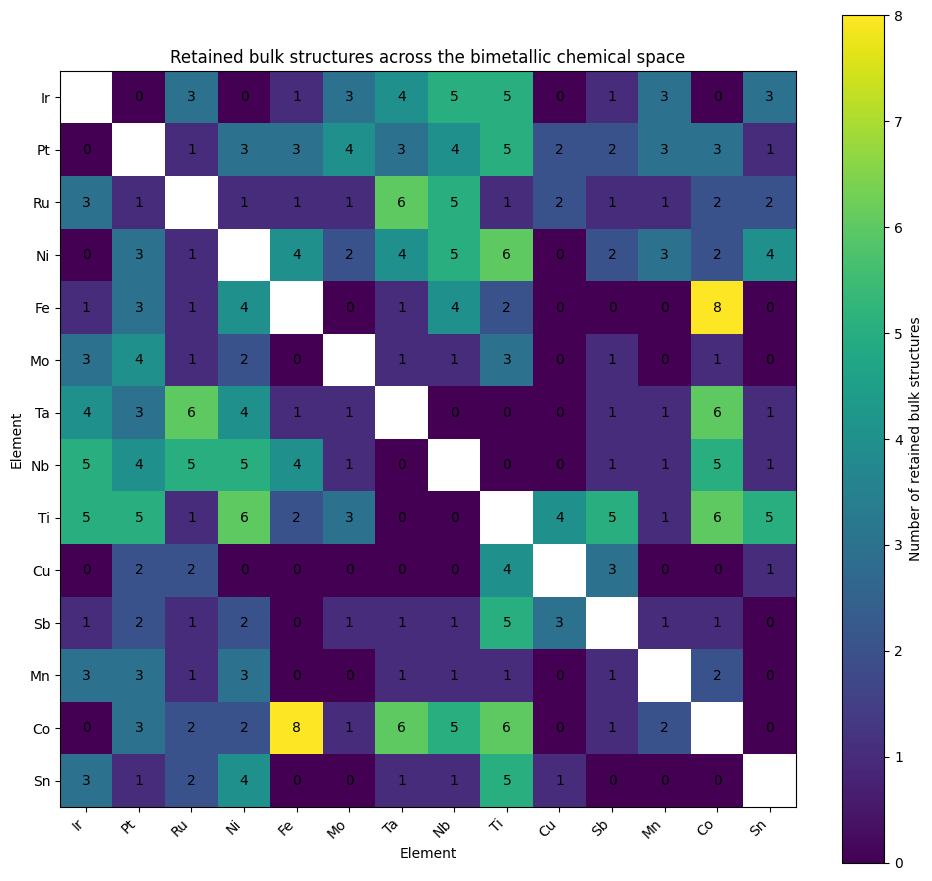

Saved: figures/bimetallic_pair_heatmap.png


In [17]:
pair_matrix = np.full(
    (len(ELEMENT_ORDER), len(ELEMENT_ORDER)),
    np.nan,
)

for i, element_i in enumerate(ELEMENT_ORDER):
    for j, element_j in enumerate(ELEMENT_ORDER):
        if i == j:
            continue

        pair = normalize_pair(f"{element_i}-{element_j}")
        pair_matrix[i, j] = pair_counts.get(pair, 0)

fig, ax = plt.subplots(figsize=(10, 9))

image = ax.imshow(pair_matrix)

ax.set_xticks(range(len(ELEMENT_ORDER)))
ax.set_xticklabels(ELEMENT_ORDER, rotation=45, ha="right")
ax.set_yticks(range(len(ELEMENT_ORDER)))
ax.set_yticklabels(ELEMENT_ORDER)
ax.set_xlabel("Element")
ax.set_ylabel("Element")
ax.set_title(
    "Retained bulk structures across the bimetallic chemical space"
)

for i in range(len(ELEMENT_ORDER)):
    for j in range(len(ELEMENT_ORDER)):
        value = pair_matrix[i, j]
        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{int(value)}",
                ha="center",
                va="center",
            )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Number of retained bulk structures")

fig.tight_layout()

heatmap_path = FIGURE_DIR / "bimetallic_pair_heatmap.png"
fig.savefig(heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", heatmap_path)

<a name="formation-energy"></a>
## 11. Formation-energy distribution

The Materials Project formation energy per atom is compared between entries
marked as experimentally observed and entries marked as theoretical only.

More negative formation energies indicate stronger stabilization relative to
the elemental reference states. The comparison is descriptive: neither the
formation energy nor the experimental-status flag is used to force the
185-material count.

In [18]:
formation_df = df_selected[
    [
        "formation_energy_per_atom",
        "experimentally_observed",
    ]
].dropna().copy()

formation_df["observation_status"] = (
    formation_df["experimentally_observed"]
    .map(
        {
            True: "Experimentally observed",
            False: "Theoretical only",
        }
    )
)

formation_summary = (
    formation_df
    .groupby("observation_status")[
        "formation_energy_per_atom"
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

formation_summary

,observation_status,count,mean,median,min,max
0,Experimentally observed,117,-0.295517,-0.260887,-1.003696,0.163046
1,Theoretical only,68,-0.125303,-0.074518,-0.913780,0.274873


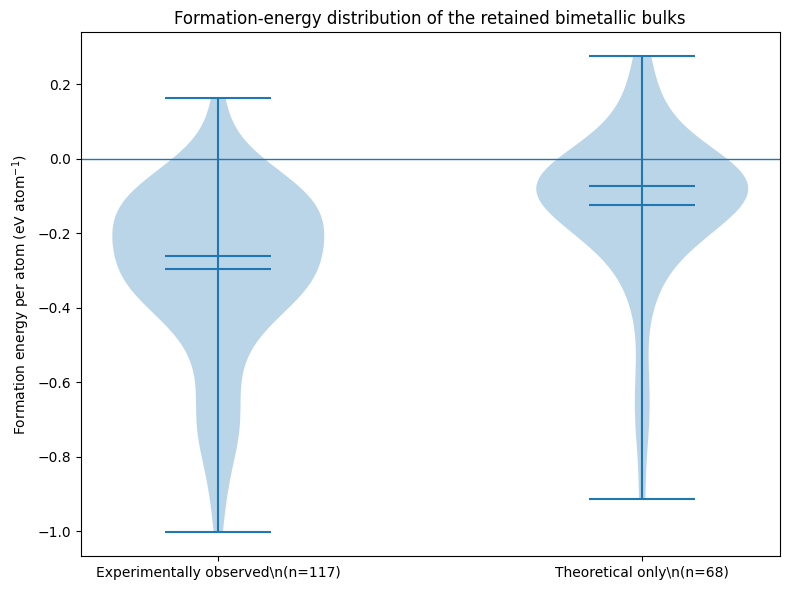

Saved: figures/formation_energy_violin.png


In [19]:
observed_values = formation_df.loc[
    formation_df["observation_status"]
    == "Experimentally observed",
    "formation_energy_per_atom",
].to_numpy()

theoretical_values = formation_df.loc[
    formation_df["observation_status"]
    == "Theoretical only",
    "formation_energy_per_atom",
].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.violinplot(
    [observed_values, theoretical_values],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
)

ax.axhline(0, linewidth=1)
ax.set_xticks([1, 2])
ax.set_xticklabels(
    [
        f"Experimentally observed\\n(n={len(observed_values)})",
        f"Theoretical only\\n(n={len(theoretical_values)})",
    ]
)
ax.set_ylabel("Formation energy per atom (eV atom$^{-1}$)")
ax.set_title(
    "Formation-energy distribution of the retained bimetallic bulks"
)

fig.tight_layout()

violin_path = FIGURE_DIR / "formation_energy_violin.png"
fig.savefig(violin_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", violin_path)

## 12. Summary

The reconstructed database contains:

| Checkpoint | Count |
|---|---:|
| OC bulk records | 11,410 |
| Binary candidates from 14 elements | 273 |
| Unique canonical MP materials | 259 |
| Current chemical/symmetry matches | 187 |
| Explicit dataset-freeze exclusions | 2 |
| Final retained bulk structures | **185** |
| Generated low-index bulk–facet systems | **555** |

The heat map shows that 68 of the 91 possible bimetallic pairs are represented,
while 23 are absent from the frozen inventory. The formation-energy comparison
contains 117 experimentally observed entries and 68 theoretical-only entries.

The final database is the bulk-structure foundation for the subsequent ORR
surface construction, adsorption-site generation, ML relaxation, and DFT
validation stages.

<a name="references"></a>
## References

1. **Chanussot, L.; Das, A.; Goyal, S.; et al.** Open Catalyst 2020
   (OC20) Dataset and Community Challenges. *ACS Catalysis* **2021**, *11*,
   6059–6072. DOI: [10.1021/acscatal.0c04525](https://doi.org/10.1021/acscatal.0c04525)

2. **Jain, A.; Ong, S. P.; Hautier, G.; et al.** Commentary: The Materials
   Project: A materials genome approach to accelerating materials innovation.
   *APL Materials* **2013**, *1*, 011002.
   DOI: [10.1063/1.4812323](https://doi.org/10.1063/1.4812323)

3. **Horton, M. K.; Huck, P.; Yang, R. X.; et al.** Accelerated
   data-driven materials science with the Materials Project.
   *Nature Materials* **2025**, *24*, 1522–1532.
   DOI: [10.1038/s41563-025-02272-0](https://doi.org/10.1038/s41563-025-02272-0)

4. **Open Catalyst Project.** Open Catalyst Dataset repository and
   `bulks.pkl` database:
   [Open-Catalyst-Dataset](https://github.com/Open-Catalyst-Project/Open-Catalyst-Dataset)

5. **Associated work.** Multi-fidelity machine-learning and DFT screening
   of bimetallic catalysts for the oxygen reduction reaction. Citation to be
   updated when the manuscript receives its final bibliographic record.

### Optional: download generated results from Colab

Run the following cell after completing the notebook. It creates one ZIP
archive containing the selected tables and pickle database.

In [20]:
import shutil

archive_path = shutil.make_archive(
    "orr_candidate_database_outputs",
    "zip",
    root_dir=".",
    base_dir="data/selected_bulks",
)

if IN_COLAB:
    from google.colab import files
    files.download(archive_path)
else:
    print("Created:", archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>